# Centrifugal compressors: from impeller sizing to production optimization

**A calculated NeqSim study of the connection between thermodynamics, rotor geometry and field production.**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/centrifugal_compressor_sizing_production_optimization.ipynb)

A compressor can satisfy a pressure specification in a process simulation while the proposed
impeller cannot deliver that head at the selected speed. This notebook keeps those calculations
connected, then asks how much a **fixed installed compressor** can produce as reservoir pressure falls.

The worked examples use synthetic, non-asset-specific inputs. Every engineering result is stored
in the notebook. The impeller calculation uses the exact source of
[NeqSim PR #3695](https://github.com/equinor/neqsim/pull/3695),
commit `ef8093d6a41c2ae25fae2cbf300275bfd6446102`, which was an open draft when this study was prepared.
This is a preliminary engineering and teaching study; its synthetic operating map is explicitly
separate from measured vendor performance and full mechanical qualification.

## What you will learn

1. Calculate real-gas head, power, temperature, density and actual inlet volume flow.
2. Size stage count and impeller diameter without breaking the head–speed relationship.
3. Reproduce the 6,000/18,000 rpm cases behind PR #3695 and expose infeasible alternatives.
4. Audit downstream stages, units, JSON exports and stale sizing results.
5. Freeze the selected geometry, construct a transparent synthetic map and optimize production.
6. Identify active constraints, driver-upgrade limits and the energy penalty of anti-surge recycle.

**Navigation:** [thermodynamics](#3.-A-composable-NeqSim-process) ·
[sizing](#6.-Why-diameter,-speed-and-head-must-be-solved-together) ·
[production](#12.-Production-potential-meets-the-installed-compressor) ·
[validation](#18.-Validation-and-reusable-results)

Background and companion examples:
[Gas compressors](GasCompressors.ipynb),
[compressor curves](compressor_curves_and_compressor_calculations.ipynb),
[capacity-aware optimization](neqsim_compressor_capacity_bottleneck_optimization.ipynb),
[mechanical design to 3D](mechanical_design_to_3d_models.ipynb), and
[the example book](../examples_of_NeqSim_in_Colab.ipynb).

## 1. Reproducible setup and the PR dependency

Run all cells in a fresh Python 3 runtime with Java JDK 17 or newer. The first source build can take
several minutes. The normal Colab path installs missing Python dependencies, checks out the pinned
NeqSim commit, and builds its runtime JAR. It never assumes the released Python package contains
this still-unmerged correction.

An optional `NEQSIM_VALIDATED_RUNTIME` manifest allows an already-built, audited copy of the same
source to be reused in CI. The source commit and JAR SHA-256 must match that manifest. The retained
execution used this path after verifying all 3,494 source/resource/POM blobs against GitHub and
compiling all 3,365 Java files with ECJ 3.41.0 at Java 17 source level, then refreshing
the three changed production classes from the final PR revision. The normal fresh-Colab Maven
bootstrap is provided but was not exercised in the restricted authoring runtime.

The next cell prints the actual method and dependency versions. Restart the runtime before
changing NeqSim JARs; a running JVM cannot unload already-loaded classes.

In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import json
import os
import shutil
import subprocess
import sys

NEQSIM_SOURCE_REF = "ef8093d6a41c2ae25fae2cbf300275bfd6446102"
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
required_packages = ["JPype1", "numpy", "pandas", "scipy", "matplotlib"]
missing_packages = []
for package in required_packages:
    try:
        version(package)
    except PackageNotFoundError:
        missing_packages.append(package)
if missing_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_packages],
        check=True,
    )

runtime_manifest = os.environ.get("NEQSIM_VALIDATED_RUNTIME")
if runtime_manifest:
    runtime = json.loads(Path(runtime_manifest).read_text())
    assert runtime["source_commit"] == NEQSIM_SOURCE_REF
    source_jar = Path(runtime["jar"]).resolve()
    actual_hash = hashlib.sha256(source_jar.read_bytes()).hexdigest()
    assert actual_hash == runtime["jar_sha256"], "Runtime JAR identity changed"
    runtime_classpath = [str(source_jar), *runtime.get("classpath", [])]
    build_method = runtime["method"]
else:
    source_root = Path("neqsim-compressor-source").resolve()
    source_root.mkdir(exist_ok=True)
    if not (source_root / ".git").exists():
        subprocess.run(["git", "init", "--quiet"], cwd=source_root, check=True)
        subprocess.run(
            ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
            cwd=source_root,
            check=True,
        )
    subprocess.run(
        ["git", "fetch", "--quiet", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
        cwd=source_root,
        check=True,
    )
    subprocess.run(
        ["git", "checkout", "--quiet", "--detach", "FETCH_HEAD"],
        cwd=source_root,
        check=True,
    )
    checked_out = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=source_root,
        text=True,
    ).strip()
    assert checked_out == NEQSIM_SOURCE_REF
    if not shutil.which("javac"):
        raise RuntimeError("Install a Java JDK 17+ (including javac), then rerun.")
    subprocess.run(
        [
            "bash",
            "mvnw",
            "-q",
            "-Dmaven.test.skip=true",
            "-Dmaven.javadoc.skip=true",
            "-Dspotless.skip=true",
            "package",
        ],
        cwd=source_root,
        check=True,
    )
    jars = [
        path
        for path in (source_root / "target").glob("neqsim-*.jar")
        if not any(token in path.name for token in ["sources", "javadoc", "tests"])
    ]
    if not jars:
        raise RuntimeError("The source build did not produce a runtime JAR.")
    source_jar = max(jars, key=lambda path: path.stat().st_size).resolve()
    actual_hash = hashlib.sha256(source_jar.read_bytes()).hexdigest()
    runtime_classpath = [str(source_jar)]
    build_method = "Pinned source checkout; Maven package with tests skipped"

print("Source commit:", NEQSIM_SOURCE_REF)
print("Build method:", build_method)
print("Runtime JAR SHA-256:", actual_hash)
print("Python:", sys.version.split()[0])
print("Python dependencies:", {package: version(package) for package in required_packages})

Source commit: ef8093d6a41c2ae25fae2cbf300275bfd6446102
Build method: ECJ 3.41.0 -17: all 3365 original Java files compiled; three updated production classes recompiled for the final PR revision; 3494 source/POM/resource Git blobs verified via the exact base tree and connector-fetched source delta
Runtime JAR SHA-256: 00fffb3d8e11a5544b8d8497b85b8e045f38075bf977981ed234d67cafca3db3
Python: 3.12.14
Python dependencies: {'JPype1': '1.7.1', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.17.0', 'matplotlib': '3.10.8'}


In [2]:
import jpype

if jpype.isJVMStarted():
    raise RuntimeError("Restart the kernel before selecting this NeqSim runtime.")
for entry in runtime_classpath:
    jpype.addClassPath(entry)
jpype.startJVM("-Xmx2g", "-Xrs", convertStrings=True)
jneqsim = jpype.JPackage("neqsim")
CompressorDesign = jpype.JClass(
    "neqsim.process.mechanicaldesign.compressor.CompressorMechanicalDesign"
)
class_origin = str(CompressorDesign.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.as_uri() == class_origin.replace("file:/", "file:///", 1)
required_methods = {"isImpellerSizingFeasible", "getImpellerSizingIssues", "getFlowCoefficient"}
assert required_methods.issubset(
    {str(method.getName()) for method in CompressorDesign.class_.getMethods()}
)
print("Loaded compressor design from:", class_origin)
print("Java:", jpype.JClass("java.lang.System").getProperty("java.version"))
print("Corrected sizing API is available.")

Loaded compressor design from: file:/workspace/scratch/7242e1797717/runtime/neqsim-pr3695.jar
Java: 17.0.20
Corrected sizing API is available.


## 2. Design basis: one dry-gas compression casing

The design point is **20 kg/s from 30 to 90 bara at 35 °C**, with a polytropic efficiency of 78% and
18,000 rpm. Pressure is absolute throughout. The composition is on a molar basis; SRK with the
classic mixing rule supplies equilibrium and caloric properties. The compressor polytropic
method is explicitly set to `schultz` to match the PR reference cases. All selected cases are checked
for a single gas phase at suction and discharge.

The process uses one casing with several impellers and an aftercooler. Multiple impellers in one
casing are different from multiple compressor sections with intercooling. There is no interstage
cooling in the initial design.

Power reported by NeqSim is work delivered to the gas. The production scenarios limit this shaft
power directly and neglect bearings, gearbox and motor losses. Add those losses to size the
motor/electrical supply. The 4.5–8 MW limits later in the notebook are synthetic study assumptions.

In [3]:
from dataclasses import dataclass
from functools import lru_cache
import math
import platform

import matplotlib.pyplot as plt
from matplotlib import patches
import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize
from IPython.display import display, Markdown

plt.rcParams.update(
    {
        "figure.figsize": (11, 4.8),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "axes.prop_cycle": plt.cycler(color=["#087f8c", "#de7535", "#384e77", "#8b5e83"]),
    }
)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 130)
pd.set_option("display.precision", 5)

COMPOSITION = {
    "methane": 0.90,
    "ethane": 0.05,
    "propane": 0.02,
    "CO2": 0.02,
    "nitrogen": 0.01,
}
assert math.isclose(sum(COMPOSITION.values()), 1.0)
P_DESIGN = 30.0
P_EXPORT = 90.0
T_SUCTION = 35.0
M_DESIGN = 20.0
ETA_POLY = 0.78
N_DESIGN = 18000.0
OUTPUT_DIR = Path("compressor_study_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

composition_table = pd.DataFrame(
    {
        "Component": list(COMPOSITION),
        "Mole fraction [-]": list(COMPOSITION.values()),
    }
)
display(composition_table)

,Component,Mole fraction [-]
0,methane,0.90
1,ethane,0.05
2,propane,0.02
3,CO2,0.02
4,nitrogen,0.01


## 3. A composable NeqSim process

The helper returns the actual `ProcessSystem`, inlet stream, compressor, aftercooler and outlet
stream. The same objects can therefore be integrated into a larger facility model. Independent
cases receive fresh fluid and equipment objects.

The main compressor operates in **specified discharge-pressure mode**. Here `setSpeed()` supplies
a sizing input; it does not by itself prove that the installed machine can reach that pressure.
The explicit fixed-geometry map introduced later supplies that missing operating constraint.

In [4]:
def make_stream(name, pressure_bara, flow_kg_s, temperature_c=T_SUCTION, composition=None):
    mixture = COMPOSITION if composition is None else composition
    fluid = SystemSrkEos(float(temperature_c + 273.15), float(pressure_bara))
    for component, mole_fraction in mixture.items():
        fluid.addComponent(component, float(mole_fraction))
    fluid.setMixingRule("classic")
    stream = Stream(name, fluid)
    stream.setFlowRate(float(flow_kg_s), "kg/sec")
    return stream


def make_compressor(name, inlet, outlet_bara, efficiency=ETA_POLY, speed_rpm=N_DESIGN):
    compressor = Compressor(name, inlet)
    compressor.setUsePolytropicCalc(True)
    compressor.setPolytropicMethod("schultz")
    compressor.setPolytropicEfficiency(float(efficiency))
    compressor.setOutletPressure(float(outlet_bara), "bara")
    compressor.setSpeed(float(speed_rpm))
    return compressor


def run_case(pressure_bara, flow_kg_s, temperature_c=T_SUCTION, efficiency=ETA_POLY):
    inlet = make_stream("Suction gas", pressure_bara, flow_kg_s, temperature_c)
    compressor = make_compressor("K-100", inlet, P_EXPORT, efficiency)
    aftercooler = Cooler("E-100", compressor.getOutletStream())
    aftercooler.setOutTemperature(float(T_SUCTION + 273.15))
    export = Stream("Export gas", aftercooler.getOutletStream())
    process = ProcessSystem()
    for equipment in [inlet, compressor, aftercooler, export]:
        process.add(equipment)
    process.run()
    inlet_fluid = inlet.getFluid()
    outlet = compressor.getOutletStream()
    for state in [inlet_fluid, outlet.getFluid()]:
        assert state.getNumberOfPhases() == 1, "This dry-gas example requires single phase."
        assert str(state.getPhase(0).getType()).lower() == "gas"
    return {
        "process": process,
        "inlet": inlet,
        "compressor": compressor,
        "aftercooler": aftercooler,
        "export": export,
        "pressure_bara": float(pressure_bara),
        "mass_kg_s": float(flow_kg_s),
        "head_kj_kg": float(compressor.getPolytropicFluidHead()),
        "power_kw": float(compressor.getPower("kW")),
        "discharge_c": float(outlet.getTemperature("C")),
        "density_kg_m3": float(inlet_fluid.getDensity("kg/m3")),
        "actual_m3_s": float(inlet.getFlowRate("m3/sec")),
        "specific_work_kj_kg": float(compressor.getPower("kW")) / flow_kg_s,
    }


design_case = run_case(P_DESIGN, M_DESIGN)
design_compressor = design_case["compressor"]
design = design_compressor.getMechanicalDesign()
design.calcDesign()
assert design.isImpellerSizingFeasible(), list(design.getImpellerSizingIssues())
print("Solved process with", design_case["process"].getUnitOperations().size(), "units.")

Solved process with 4 units.


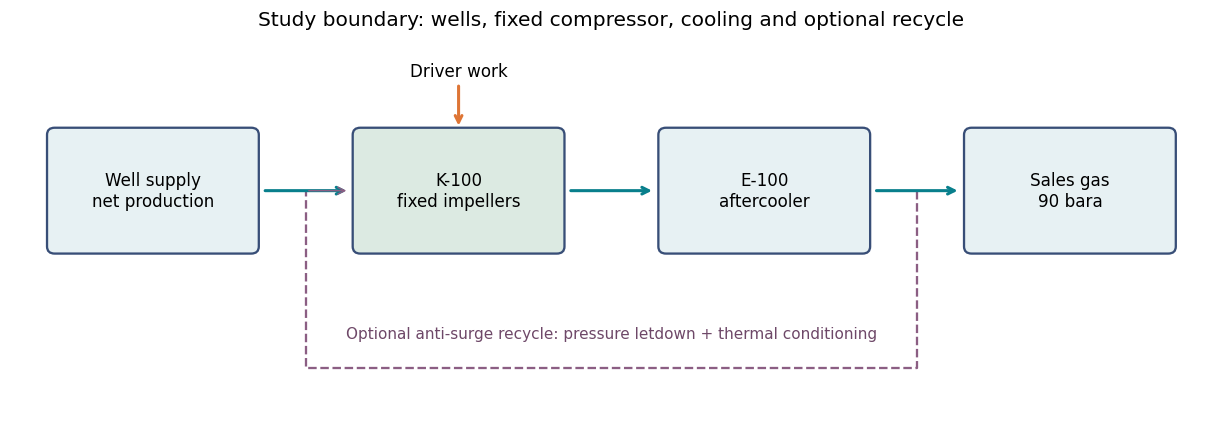

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.8), layout="constrained")
ax.set(xlim=(0, 11), ylim=(0, 3.7))
ax.axis("off")
boxes = [
    (0.4, "Well supply\nnet production", "#e7f1f3"),
    (3.2, "K-100\nfixed impellers", "#dceae2"),
    (6.0, "E-100\naftercooler", "#e7f1f3"),
    (8.8, "Sales gas\n90 bara", "#e7f1f3"),
]
for horizontal, label, color in boxes:
    ax.add_patch(
        patches.FancyBboxPatch(
            (horizontal, 1.7),
            1.8,
            1.1,
            boxstyle="round,pad=0.07",
            facecolor=color,
            edgecolor="#384e77",
            linewidth=1.5,
        )
    )
    ax.text(horizontal + 0.9, 2.25, label, ha="center", va="center")
for start, end in [(2.3, 3.1), (5.1, 5.9), (7.9, 8.7)]:
    ax.annotate(
        "",
        xy=(end, 2.25),
        xytext=(start, 2.25),
        arrowprops={"arrowstyle": "->", "lw": 2, "color": "#087f8c"},
    )
ax.annotate(
    "Driver work",
    xy=(4.1, 2.86),
    xytext=(4.1, 3.38),
    ha="center",
    arrowprops={"arrowstyle": "->", "color": "#de7535", "lw": 2},
)
ax.plot([8.3, 8.3, 2.7, 2.7], [2.25, 0.5, 0.5, 2.25], "--", color="#8b5e83")
ax.annotate(
    "", xy=(3.1, 2.25), xytext=(2.7, 2.25), arrowprops={"arrowstyle": "->", "color": "#8b5e83"}
)
ax.text(
    5.5,
    0.8,
    "Optional anti-surge recycle: pressure letdown + thermal conditioning",
    ha="center",
    color="#6e4868",
    fontsize=10,
)
ax.set_title("Study boundary: wells, fixed compressor, cooling and optional recycle", pad=12)
plt.show()

## 4. Head, work and flow: keep the units explicit

For an adiabatic compressor, neglecting changes in stream kinetic/potential energy:

$$\dot W_{\mathrm{gas}}=\dot m(h_2-h_1)$$

Here mass flow $\dot m$ is in kg/s, specific enthalpy $h$ in kJ/kg and power in kW. The NeqSim
polytropic head $H_p$ is in kJ/kg; for the selected calculation method, the gas work is
$H_p/\eta_p$. The energy-balance check below uses actual inlet/outlet enthalpies independently.

Sizing uses **actual suction flow**, not a standard volume rate:

$$Q_1=\frac{\dot m}{\rho_1}$$

Here $Q_1$ is in m³/s and suction density $\rho_1$ in kg/m³. A common error is to mix m³/h with
m³/s or confuse standard flow with actual flow. The printed standard-flow reference is the
NeqSim convention of 15 °C and 1.01325 bara.

In [6]:
inlet = design_case["inlet"]
outlet = design_compressor.getOutletStream()
h_in_kj_kg = inlet.getFluid().getEnthalpy("J/kg") / 1000.0
h_out_kj_kg = outlet.getFluid().getEnthalpy("J/kg") / 1000.0
enthalpy_power_kw = M_DESIGN * (h_out_kj_kg - h_in_kj_kg)
energy_residual_kw = enthalpy_power_kw - design_case["power_kw"]
mass_residual = outlet.getFlowRate("kg/sec") - inlet.getFlowRate("kg/sec")
component_residuals = []
for index in range(inlet.getFluid().getNumberOfComponents()):
    inlet_moles = inlet.getFluid().getComponent(index).getNumberOfmoles()
    outlet_moles = outlet.getFluid().getComponent(index).getNumberOfmoles()
    component_residuals.append(abs(outlet_moles - inlet_moles) / max(abs(inlet_moles), 1.0))

thermo_table = pd.DataFrame(
    [
        ["Suction pressure", P_DESIGN, "bara"],
        ["Export pressure", P_EXPORT, "bara"],
        ["Gas mass flow", M_DESIGN, "kg/s"],
        ["Actual suction volume flow", design_case["actual_m3_s"], "m³/s"],
        ["Standard gas flow", inlet.getFlowRate("MSm3/day"), "million Sm³/day"],
        ["Suction density", design_case["density_kg_m3"], "kg/m³"],
        ["Polytropic head", design_case["head_kj_kg"], "kJ/kg"],
        ["Gas work", design_case["specific_work_kj_kg"], "kJ/kg"],
        ["Gas power", design_case["power_kw"], "kW"],
        ["Discharge temperature", design_case["discharge_c"], "°C"],
        ["Aftercooler duty", design_case["aftercooler"].getDuty() / 1000.0, "kW"],
    ],
    columns=["Quantity", "Calculated value", "Unit"],
)
display(thermo_table)
print(f"Mass residual: {mass_residual:.3e} kg/s")
print(f"Maximum component relative residual: {max(component_residuals):.3e}")
print(f"Power minus enthalpy-rise residual: {-energy_residual_kw:.3e} kW")

Mass residual: 0.000e+00 kg/s
Maximum component relative residual: 0.000e+00
Power minus enthalpy-rise residual: 9.095e-13 kW


,Quantity,Calculated value,Unit
0,Suction pressure,30.00000,bara
1,Export pressure,90.00000,bara
2,Gas mass flow,20.00000,kg/s
3,Actual suction volume flow,0.89858,m³/s
4,Standard gas flow,2.27186,million Sm³/day
5,Suction density,22.25746,kg/m³
6,Polytropic head,176.33011,kJ/kg
7,Gas work,226.06425,kJ/kg
8,Gas power,4521.28495,kW
9,Discharge temperature,142.21851,°C


## 5. An independent perfect-gas reasonableness check

An inlet-property, constant-$k$, perfect-gas approximation gives:

$$a=\frac{k-1}{k\eta_p},\qquad T_2^{\mathrm{ideal}}=T_1r^a$$
$$H_p^{\mathrm{ideal}}=\frac{R_sT_1}{1000a}(r^a-1)$$

The pressure ratio is $r=p_2/p_1$, the specific gas constant is $R_s=R/M$ in J/(kg K), and
$k=C_p/C_v$ is evaluated at the NeqSim inlet. Temperatures are in kelvin. This comparison is an
independent equation check, but its inlet $k$ and molecular mass come from NeqSim. It is **not**
a high-pressure real-gas benchmark; deviations are expected because compressibility and heat
capacity change during compression.

In [7]:
fluid = inlet.getFluid()
k_inlet = fluid.getCp("J/kgK") / fluid.getCv("J/kgK")
specific_gas_constant = 8.314462618 / fluid.getMolarMass("kg/mol")
pressure_ratio = P_EXPORT / P_DESIGN
exponent = (k_inlet - 1.0) / (k_inlet * ETA_POLY)
ideal_temperature_c = (T_SUCTION + 273.15) * pressure_ratio**exponent - 273.15
ideal_head = (
    specific_gas_constant
    * (T_SUCTION + 273.15)
    * (pressure_ratio**exponent - 1.0)
    / (1000.0 * exponent)
)
comparison = pd.DataFrame(
    {
        "Method": ["SRK NeqSim", "Constant-k perfect gas"],
        "Head [kJ/kg]": [design_case["head_kj_kg"], ideal_head],
        "Power [kW]": [design_case["power_kw"], M_DESIGN * ideal_head / ETA_POLY],
        "Discharge [°C]": [design_case["discharge_c"], ideal_temperature_c],
    }
)
display(comparison)
ideal_head_difference = 100.0 * (ideal_head / design_case["head_kj_kg"] - 1.0)
print(f"Perfect-gas head difference relative to SRK: {ideal_head_difference:.2f}%")

Perfect-gas head difference relative to SRK: 8.35%


,Method,Head [kJ/kg],Power [kW],Discharge [°C]
0,SRK NeqSim,176.33011,4521.28495,142.21851
1,Constant-k perfect gas,191.04638,4898.62515,180.32975


## 6. Why diameter, speed and head must be solved together

For diameter $D$ in metres and shaft speed $N$ in rpm, the tip speed $U$ is:

$$U=\frac{\pi DN}{60}$$

PR #3695 uses a fixed, effective polytropic work coefficient $\psi=0.50$ and equal head per impeller:

$$H_{\mathrm{stage}}=\frac{H_p}{z}=\frac{\psi U^2}{1000}$$
$$D=\frac{60}{\pi N}\sqrt{\frac{1000H_p}{z\psi}}$$

Here $z$ is the integer number of impellers and head is in kJ/kg. This coefficient is a
preliminary model assumption, not a universal blade/slip-factor correlation. Euler's underlying
work transfer depends on inlet/outlet swirl; a real impeller requires blade geometry, slip,
diffuser and loss calculations or measured maps.

The model's inlet flow coefficient is:

$$\phi=\frac{Q_1}{D^2U}$$

This particular definition does not include additional area constants. Literature and supplier
maps may use other definitions; convert them before comparing coefficients.

**The correction:** never change or clamp $D$ to improve $\phi$ while retaining the old $U$ and
head. At fixed speed, a 20% diameter reduction reduces tip speed by 20% and head capability by
36%. Stage count, speed, total head and flow must be reconsidered together.

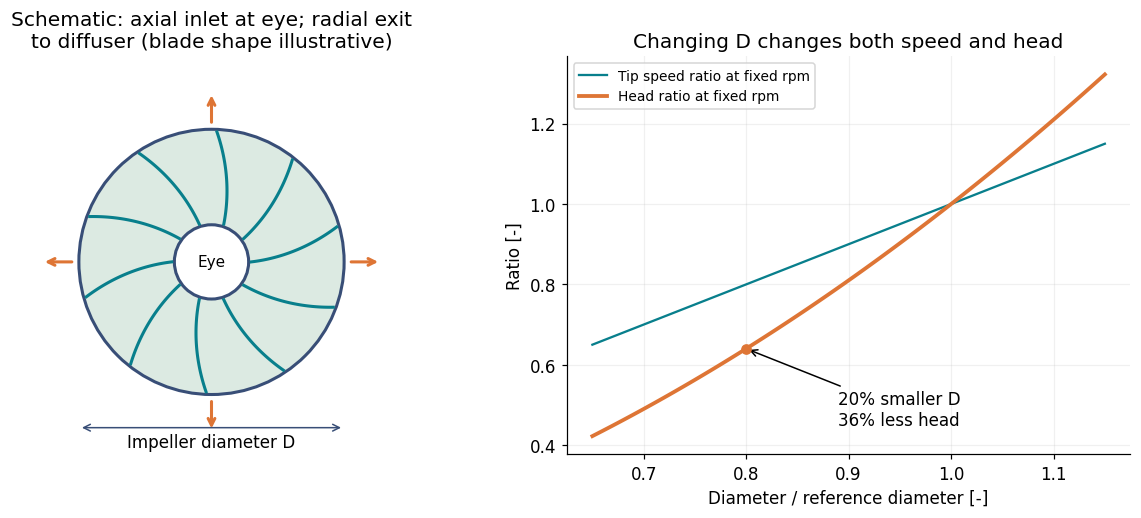

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), layout="constrained")
ax = axes[0]
ax.set_aspect("equal")
ax.set(xlim=(-1.5, 1.5), ylim=(-1.45, 1.55))
ax.axis("off")
for radius, color in [(1.0, "#dceae2"), (0.28, "white")]:
    ax.add_patch(patches.Circle((0, 0), radius, facecolor=color, edgecolor="#384e77", lw=2))
for angle in np.linspace(0, 2 * np.pi, 10, endpoint=False):
    radius = np.linspace(0.3, 0.98, 50)
    theta = angle + 0.4 * (radius - 0.3)
    ax.plot(radius * np.cos(theta), radius * np.sin(theta), color="#087f8c", lw=2)
for angle in np.linspace(0, 2 * np.pi, 4, endpoint=False):
    ax.annotate(
        "",
        xy=(1.28 * np.cos(angle), 1.28 * np.sin(angle)),
        xytext=(1.03 * np.cos(angle), 1.03 * np.sin(angle)),
        arrowprops={"arrowstyle": "->", "color": "#de7535", "lw": 2},
    )
ax.text(0, 0, "Eye", ha="center", va="center", fontsize=10)
ax.annotate(
    "", xy=(1, -1.25), xytext=(-1, -1.25), arrowprops={"arrowstyle": "<->", "color": "#384e77"}
)
ax.text(0, -1.4, "Impeller diameter D", ha="center")
ax.set_title("Schematic: axial inlet at eye; radial exit\nto diffuser (blade shape illustrative)")
ratio = np.linspace(0.65, 1.15, 101)
axes[1].plot(ratio, ratio, label="Tip speed ratio at fixed rpm")
axes[1].plot(ratio, ratio**2, label="Head ratio at fixed rpm", lw=2.5)
axes[1].scatter([0.8], [0.64], color="#de7535", zorder=5)
axes[1].annotate(
    "20% smaller D\n36% less head",
    xy=(0.8, 0.64),
    xytext=(0.89, 0.45),
    arrowprops={"arrowstyle": "->"},
)
axes[1].set(
    xlabel="Diameter / reference diameter [-]",
    ylabel="Ratio [-]",
    title="Changing D changes both speed and head",
)
axes[1].legend(fontsize=9)
plt.show()

## 7. Reproduce PR #3695: 6,000 rpm versus 18,000 rpm

This separate regression uses the exact public teaching mixture: 80% methane, 5% ethane,
5% propane and 10% n-decane at 20 bara and 40 °C; total feed 100,000 kg/h. A separator removes
liquid before gas compression to 80 bara. Compressor mass flow is therefore **less than total
wellstream mass flow**.

The corrected algorithm tries stage counts from the minimum head-based count up to the casing
limit. If none passes, it retains the initial head-based candidate for diagnostics and reports
infeasibility. It does not return a deceptively adjusted diameter.

In [9]:
rich_composition = {"methane": 0.80, "ethane": 0.05, "propane": 0.05, "n-decane": 0.10}
reference_feed = make_stream(
    "Rich reference feed", 20.0, 100000.0 / 3600.0, 40.0, rich_composition
)
reference_separator = Separator("Reference separator", reference_feed)
reference_process = ProcessSystem()
reference_process.add(reference_feed)
reference_process.add(reference_separator)
reference_process.run()
reference_gas = reference_separator.getGasOutStream()
reference_rows = []
reference_designs = {}
for speed in [6000.0, 18000.0]:
    compressor = make_compressor(
        f"Reference {speed:.0f} rpm", reference_gas, 80.0, speed_rpm=speed
    )
    compressor.run()
    sizing = compressor.getMechanicalDesign()
    sizing.calcDesign()
    reference_designs[speed] = (compressor, sizing)
    reference_rows.append(
        {
            "Speed [rpm]": speed,
            "Impellers": sizing.getNumberOfStages(),
            "Diameter [mm]": sizing.getImpellerDiameter(),
            "Tip speed [m/s]": sizing.getTipSpeed(),
            "Head [kJ/kg]": compressor.getPolytropicFluidHead(),
            "Inlet phi [-]": sizing.getFlowCoefficient(),
            "Passes screen": bool(sizing.isImpellerSizingFeasible()),
        }
    )
reference_table = pd.DataFrame(reference_rows)
display(reference_table)
print(f"Feed mass flow: {reference_feed.getFlowRate('kg/sec'):.5f} kg/s")
print(f"Compressor gas flow: {reference_gas.getFlowRate('kg/sec'):.5f} kg/s")
print("6000 rpm diagnostics:", list(reference_designs[6000.0][1].getImpellerSizingIssues()))
assert not reference_designs[6000.0][1].isImpellerSizingFeasible()
assert reference_designs[18000.0][1].isImpellerSizingFeasible()
assert reference_designs[18000.0][1].getNumberOfStages() == 8

Feed mass flow: 27.77778 kg/s
Compressor gas flow: 14.44883 kg/s
6000 rpm diagnostics: ['Impeller inlet flow coefficient 0.006958001105703654 is outside 0.01-0.15 at the specified shaft speed.']


,Speed [rpm],Impellers,Diameter [mm],Tip speed [m/s],Head [kJ/kg],Inlet phi [-],Passes screen
0,6000.0,8,769.12405,241.62745,233.53529,0.00696,False
1,18000.0,8,256.37468,241.62745,233.53529,0.06262,True


## 8. Independently enumerate the preliminary sizing candidates

The following limits are the **PR's model settings**, not general industry acceptance criteria:

| Screen | Value |
|---|---:|
| Effective work coefficient | 0.50 |
| Maximum head per impeller | 30 kJ/kg |
| Impeller diameter | 100–1500 mm |
| Maximum tip speed | 350 m/s |
| Inlet flow coefficient | 0.01–0.15 |
| Default maximum impellers per casing | 10 |

The 30 kJ/kg head limit and fixed coefficient already imply $U\leq244.95$ m/s for an accepted
candidate, so the separate 350 m/s limit is not the active limit in this example. Increasing the
number of equal-head impellers reduces $D$ and $U$ and **increases** inlet $\phi$. At a fixed head,
$D$ scales as $1/(N\sqrt{z})$ and $\phi$ as $N^2z^{3/2}$.

In [10]:
def impeller_candidates(head_kj_kg, actual_m3_s, speed_rpm, max_stages=10):
    if min(head_kj_kg, actual_m3_s, speed_rpm) <= 0:
        raise ValueError("Head, actual flow and speed must be positive.")
    rows = []
    minimum_stages = math.ceil(head_kj_kg / 30.0)
    for stages in range(minimum_stages, max(max_stages, minimum_stages) + 1):
        stage_head = head_kj_kg / stages
        tip_speed = math.sqrt(stage_head * 1000.0 / 0.50)
        diameter_m = 60.0 * tip_speed / (math.pi * speed_rpm)
        coefficient = actual_m3_s / (diameter_m**2 * tip_speed)
        checks = {
            "stage count": stages <= max_stages,
            "stage head": stage_head <= 30.0,
            "diameter": 0.1 <= diameter_m <= 1.5,
            "tip speed": tip_speed <= 350.0,
            "inlet flow": 0.01 <= coefficient <= 0.15,
        }
        rows.append(
            {
                "Impellers": stages,
                "Head/stage [kJ/kg]": stage_head,
                "Diameter [mm]": 1000.0 * diameter_m,
                "Tip speed [m/s]": tip_speed,
                "Inlet phi [-]": coefficient,
                "Passes": all(checks.values()),
                "Failed limits": ", ".join(key for key, value in checks.items() if not value),
            }
        )
    return pd.DataFrame(rows)


candidates = impeller_candidates(
    design_case["head_kj_kg"],
    design_case["actual_m3_s"],
    N_DESIGN,
)
display(candidates)
selected_candidate = candidates[candidates["Passes"]].iloc[0]
assert int(selected_candidate["Impellers"]) == design.getNumberOfStages()
assert math.isclose(
    selected_candidate["Diameter [mm]"], design.getImpellerDiameter(), rel_tol=1e-12
)
print("Python enumeration and NeqSim select the same first feasible candidate.")

Python enumeration and NeqSim select the same first feasible candidate.


,Impellers,Head/stage [kJ/kg],Diameter [mm],Tip speed [m/s],Inlet phi [-],Passes,Failed limits
0,6,29.38835,257.23585,242.43907,0.05601,True,
1,7,25.19002,238.15412,224.45497,0.07058,True,
2,8,22.04126,222.77278,209.95840,0.08624,True,
3,9,19.59223,210.03219,197.95067,0.10290,True,
4,10,17.63301,199.25403,187.79250,0.12052,True,


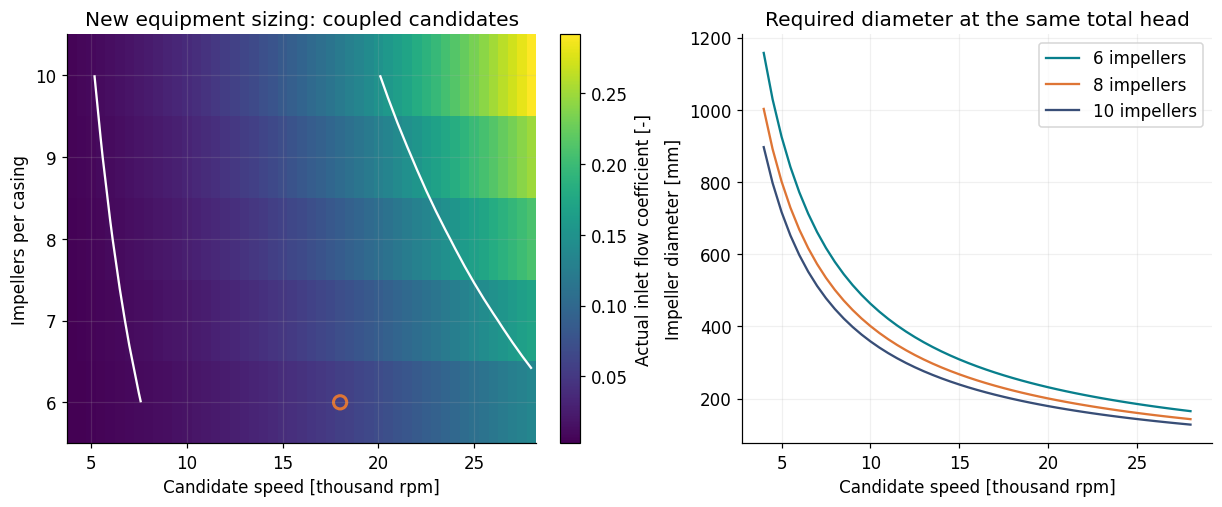

In [11]:
speed_grid = np.arange(4000.0, 28001.0, 500.0)
stage_grid = np.arange(6, 11)
phi_values = np.empty((len(stage_grid), len(speed_grid)))
pass_values = np.zeros_like(phi_values, dtype=bool)
for column, speed in enumerate(speed_grid):
    sweep = impeller_candidates(design_case["head_kj_kg"], design_case["actual_m3_s"], speed)
    phi_values[:, column] = sweep["Inlet phi [-]"].to_numpy()
    pass_values[:, column] = sweep["Passes"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
mesh = axes[0].pcolormesh(
    speed_grid / 1000.0, stage_grid, phi_values, shading="nearest", cmap="viridis"
)
axes[0].contour(speed_grid / 1000.0, stage_grid, phi_values, levels=[0.01, 0.15], colors="white")
fig.colorbar(mesh, ax=axes[0], label="Actual inlet flow coefficient [-]")
axes[0].scatter(
    [N_DESIGN / 1000.0],
    [design.getNumberOfStages()],
    s=75,
    facecolor="none",
    edgecolor="#de7535",
    linewidth=2,
)
axes[0].set(
    xlabel="Candidate speed [thousand rpm]",
    ylabel="Impellers per casing",
    title="New equipment sizing: coupled candidates",
    yticks=stage_grid,
)
for stages in [6, 8, 10]:
    tip = math.sqrt(1000.0 * design_case["head_kj_kg"] / (0.5 * stages))
    diameters_mm = 60000.0 * tip / (np.pi * speed_grid)
    axes[1].plot(speed_grid / 1000.0, diameters_mm, label=f"{stages} impellers")
axes[1].set(
    xlabel="Candidate speed [thousand rpm]",
    ylabel="Impeller diameter [mm]",
    title="Required diameter at the same total head",
)
axes[1].legend()
plt.show()

A higher design speed can make this low-flow service pass the preliminary screen, but that alone
does not justify a high-speed machine: driver/gearbox compatibility, stress, rotor dynamics,
critical speeds, seals, noise and maintenance remain separate design decisions. Likewise, adding
impellers is limited by casing length, shaft behavior and stage matching.

An especially important production-optimization distinction follows: the curves above describe
**different possible new machines**. Once a machine is selected, its diameter and impeller count
are frozen. Re-running `calcDesign()` at every operating point would silently redesign the machine.

## 9. Audit the downstream impellers

Passing the inlet screen does not qualify every downstream stage. Gas density rises through the
casing, so actual volume flow decreases. We now solve six consecutive **equal-head** compression
steps, without intercooling, using the same efficiency. Each stage discharge pressure is found
by a scalar root solve. This is a thermodynamic stage allocation, not an aerodynamic stage model.

The diameter and tip speed from the design point are held fixed while the stage-inlet flow
coefficient is recalculated. A real design may use different widths, blade angles or stage families.
The final pressure is compared with the single-casing calculation; the end-state Schultz
approximation does not compose exactly when split across multiple equipment objects. The
allowed reconstruction difference for this teaching audit is 0.5%; a pressure-specified final
train must be solved to its outlet target independently.

In [12]:
stages_selected = int(design.getNumberOfStages())
diameter_selected_m = design.getImpellerDiameter() / 1000.0
tip_selected_m_s = design.getTipSpeed()
head_target_per_stage = design_case["head_kj_kg"] / stages_selected
stage_inlet = Stream("Stage 1 inlet", inlet.getFluid().clone())
stage_inlet.run()
stage_rows = []
stage_compressors = []
for stage_number in range(1, stages_selected + 1):
    pressure_in = stage_inlet.getPressure("bara")
    stage_compressor = make_compressor(f"Impeller {stage_number}", stage_inlet, pressure_in * 1.3)

    def head_error(outlet_pressure):
        stage_compressor.setOutletPressure(float(outlet_pressure), "bara")
        stage_compressor.run()
        return stage_compressor.getPolytropicFluidHead() - head_target_per_stage

    pressure_out = brentq(head_error, pressure_in * 1.00001, pressure_in * 3.0, xtol=1e-9)
    head_error(pressure_out)
    volume_in = stage_inlet.getFlowRate("m3/sec")
    stage_rows.append(
        {
            "Stage": stage_number,
            "Inlet [bara]": pressure_in,
            "Outlet [bara]": pressure_out,
            "Inlet [°C]": stage_inlet.getTemperature("C"),
            "Inlet flow [m³/s]": volume_in,
            "Head [kJ/kg]": stage_compressor.getPolytropicFluidHead(),
            "Inlet phi [-]": volume_in / (diameter_selected_m**2 * tip_selected_m_s),
        }
    )
    stage_compressors.append(stage_compressor)
    stage_inlet = stage_compressor.getOutletStream()

stage_audit = pd.DataFrame(stage_rows)
display(stage_audit)
stage_pressure_difference = 100.0 * (stage_inlet.getPressure("bara") / P_EXPORT - 1.0)
print(f"Final pressure difference versus single-casing model: {stage_pressure_difference:.5f}%")
print("This table does not validate downstream blade/diffuser performance.")

Final pressure difference versus single-casing model: 0.35169%
This table does not validate downstream blade/diffuser performance.


,Stage,Inlet [bara],Outlet [bara],Inlet [°C],Inlet flow [m³/s],Head [kJ/kg],Inlet phi [-]
0,1,30.00000,37.04542,35.00000,0.89858,29.38835,0.05601
1,2,37.04542,45.17339,54.10791,0.77528,29.38835,0.04833
2,3,45.17339,54.47415,72.72444,0.67468,29.38835,0.04206
3,4,54.47415,65.03836,90.84666,0.59169,29.38835,0.03688
4,5,65.03836,76.95623,108.47582,0.52261,29.38835,0.03258
5,6,76.95623,90.31652,125.61613,0.46462,29.38835,0.02896


## 10. Export a checked design basis and demonstrate stale-state protection

`toJson()` uses legacy compressor units: diameter in mm and head per stage in kJ/kg.
`toDesignDataJson()` uses explicitly labelled geometry in metres and head per stage in J/kg.
Always read the unit alongside the value.

The CAD export has an `impellerSizingFeasible` flag and diagnostics. A valid casing envelope or
`geometryConsistency` flag alone does not establish impeller feasibility. Zero-speed input is also checked: unavailable impeller quantities must serialize as `null`,
with zero selected stages. The data below can support a concept CAD envelope; it does not define manufacturable blade passages or tolerances.

In [13]:
legacy_design = json.loads(str(design.toJson()))
cad_design = json.loads(str(design.toDesignDataJson()))
assert cad_design["impellerSizingFeasible"]
assert not cad_design["impellerSizingIssues"]
cad_basis = cad_design["designBasis"]
cad_geometry = cad_design["geometry"]
export_rows = []
for name in ["impellerSizingSpeed", "impellerTipSpeed", "inletFlowCoefficient", "headPerStage"]:
    quantity = cad_basis[name]
    export_rows.append([name, quantity["value"], quantity["unit"]])
export_rows.append(
    [
        "impellerDiameter",
        cad_geometry["impellerDiameter"]["value"],
        cad_geometry["impellerDiameter"]["unit"],
    ]
)
display(pd.DataFrame(export_rows, columns=["Export field", "Value", "Unit"]))
assert math.isclose(
    cad_geometry["impellerDiameter"]["value"] * 1000.0,
    legacy_design["impellerDiameter"],
    rel_tol=1e-12,
)
assert cad_basis["headPerStage"]["unit"] == "J/kg"
assert math.isclose(
    cad_basis["headPerStage"]["value"] / 1000.0, legacy_design["headPerStage"], rel_tol=1e-12
)
(OUTPUT_DIR / "preliminary_compressor_design.json").write_text(
    json.dumps(cad_design, indent=2, allow_nan=False)
)

design_compressor.setSpeed(17000.0)
stale_rejected = not design.isImpellerSizingFeasible()
print("Changing speed invalidates the old sizing:", stale_rejected)
print("Diagnostic:", list(design.getImpellerSizingIssues()))
assert stale_rejected
design_compressor.setSpeed(N_DESIGN)
design_compressor.run()
design.calcDesign()
assert design.isImpellerSizingFeasible()

# Invalid inputs must not retain a previously feasible impeller geometry.
design_compressor.setSpeed(0.0)
design.calcDesign()
invalid_export = json.loads(str(design.toJson()))
invalid_inputs_cleared = (
    not design.isImpellerSizingFeasible()
    and invalid_export["impellerDiameter"] is None
    and invalid_export["headPerStage"] is None
    and design.getNumberOfStages() == 0
)
assert invalid_inputs_cleared
print("Zero-speed export clears stale impeller geometry:", invalid_inputs_cleared)
design_compressor.setSpeed(N_DESIGN)
design_compressor.run()
design.calcDesign()
assert design.isImpellerSizingFeasible()

Changing speed invalidates the old sizing: True
Diagnostic: ['Compressor speed, inlet flow or head changed after sizing; rerun the process and calcDesign().']
Zero-speed export clears stale impeller geometry: True


,Export field,Value,Unit
0,impellerSizingSpeed,18000.00000,rpm
1,impellerTipSpeed,242.43907,m/s
2,inletFlowCoefficient,0.05601,1
3,headPerStage,29388.35221,J/kg
4,impellerDiameter,0.25724,m


## 11. Freeze the installed machine and define a transparent synthetic map

We retain six impellers and the selected diameter. A simple declining head curve is anchored at
the design point:

$$\psi(\phi)=0.50\left[1.18-0.18\frac{\phi}{\phi_d}\right]$$
$$H_{\mathrm{map}}=\frac{z\psi(\phi)U^2}{1000}$$

The design flow coefficient is $\phi_d$. This invented curve is used to teach system coupling;
no vendor or public compressor data have been fitted. Its effective efficiency is held at 0.78
throughout. Affinity scaling is assumed at unchanged gas composition, with no Reynolds, Mach,
clearance or inlet-guide-vane corrections. An equal-diameter casing map also does not capture
downstream stage matching.

The illustrative surge line is $\phi_s=0.50\phi_d$. A 10% **flow-based** control margin requires
$\phi\geq1.10\phi_s=0.55\phi_d$. The high-flow operating boundary is $1.50\phi_d$; it is a
synthetic boundary, not a calculated sonic throat. The operating speed interval is 12,000–19,800
rpm. We also retain the preliminary 30 kJ/kg maximum head per impeller as a conservative
operating constraint. Exceeding that limit would require a revised design basis and stage
qualification. These map limits supplement the preliminary sizing screen.

Frozen geometry: 6 impellers, 257.236 mm.


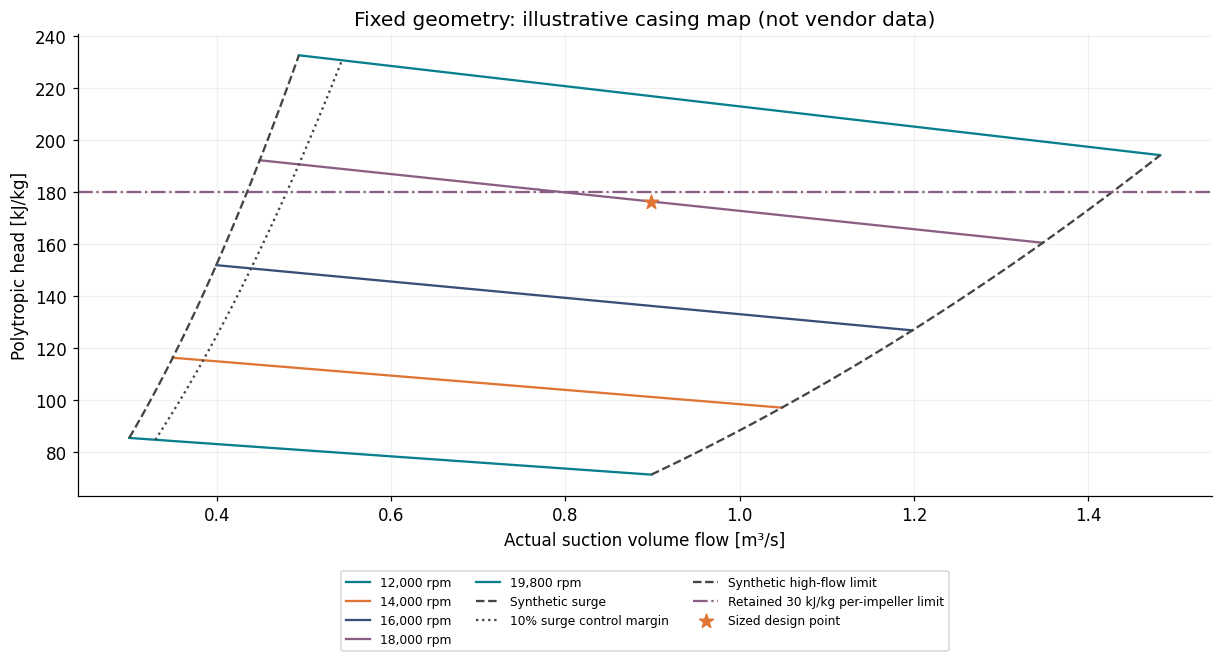

In [14]:
@dataclass(frozen=True)
class InstalledCompressor:
    diameter_m: float
    impellers: int
    design_phi: float
    minimum_rpm: float = 12000.0
    maximum_rpm: float = 19800.0
    maximum_discharge_c: float = 165.0
    maximum_tip_m_s: float = 350.0
    maximum_stage_head_kj_kg: float = 30.0


installed = InstalledCompressor(
    diameter_m=diameter_selected_m,
    impellers=stages_selected,
    design_phi=float(design.getFlowCoefficient()),
)
geometry_identity = (installed.diameter_m, installed.impellers)


def map_coefficient(phi):
    return 0.50 * (1.18 - 0.18 * np.asarray(phi) / installed.design_phi)


def map_head(actual_flow_m3_s, speed_rpm):
    tip_speed = np.pi * installed.diameter_m * np.asarray(speed_rpm) / 60.0
    phi = np.asarray(actual_flow_m3_s) / (installed.diameter_m**2 * tip_speed)
    return installed.impellers * map_coefficient(phi) * tip_speed**2 / 1000.0


assert math.isclose(
    map_head(design_case["actual_m3_s"], N_DESIGN), design_case["head_kj_kg"], rel_tol=1e-10
)
map_records = []
fig, ax = plt.subplots(figsize=(11, 5.9), layout="constrained")
for speed in [12000, 14000, 16000, 18000, 19800]:
    tip = np.pi * installed.diameter_m * speed / 60.0
    phi = np.linspace(0.50, 1.50, 70) * installed.design_phi
    volume = phi * installed.diameter_m**2 * tip
    head = map_head(volume, speed)
    ax.plot(volume, head, label=f"{speed:,} rpm")
    map_records.extend(zip(np.full(len(phi), speed), volume, head, phi))
for ratio, label, style in [
    (0.50, "Synthetic surge", "--"),
    (0.55, "10% surge control margin", ":"),
    (1.50, "Synthetic high-flow limit", "--"),
]:
    speeds = np.linspace(installed.minimum_rpm, installed.maximum_rpm, 70)
    tips = np.pi * installed.diameter_m * speeds / 60.0
    volume = ratio * installed.design_phi * installed.diameter_m**2 * tips
    ax.plot(volume, map_head(volume, speeds), style, color="#444444", label=label)
ax.axhline(
    30.0 * installed.impellers,
    color="#8b5e83",
    ls="-.",
    label="Retained 30 kJ/kg per-impeller limit",
)
ax.scatter(
    [design_case["actual_m3_s"]],
    [design_case["head_kj_kg"]],
    s=90,
    marker="*",
    color="#de7535",
    zorder=5,
    label="Sized design point",
)
ax.set(
    xlabel="Actual suction volume flow [m³/s]",
    ylabel="Polytropic head [kJ/kg]",
    title="Fixed geometry: illustrative casing map (not vendor data)",
)
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.show()
map_table = pd.DataFrame(
    map_records, columns=["Speed [rpm]", "Flow [m³/s]", "Head [kJ/kg]", "phi [-]"]
)
print(f"Frozen geometry: {installed.impellers} impellers, {installed.diameter_m * 1000:.3f} mm.")

## 12. Production potential meets the installed compressor

A synthetic aggregate well-deliverability relation supplies a pressure-dependent upper rate:

$$\dot m_{\mathrm{potential}}=J\sqrt{p_r^2-p_s^2}$$

Here $p_r$ is an effective reservoir pressure, $p_s$ the compressor suction pressure (both bara),
and $J=0.68$ kg/(s bar). This toy relation lumps the wells and gathering network; it is not a
reservoir/wellbore simulator. Actual well rate can be reduced below potential by choking.
Production optimization varies suction pressure and **net exported mass flow**.

At each trial point, a fresh SRK compressor calculation at 1 kg/s supplies head, density,
discharge temperature and specific work. These intensive results scale linearly with flow for
this specified-efficiency, specified-pressure process. The independent final replay at the full
optimized flow verifies that scaling. A cache reuses identical pressure/efficiency calculations;
it does not interpolate or replace thermodynamics.

For this synthetic map, the required tip speed follows a quadratic equation, avoiding a nested
map solver. With $b=0.18Q/(D^2\phi_d)$ and $H_p$ in kJ/kg:

$$U=\frac{b+\sqrt{b^2+4(1.18)(1000H_p)/(0.50z)}}{2(1.18)}$$

This identity keeps the installed diameter and impeller count fixed. We still check the speed,
flow boundaries, temperature, power, positive map coefficient and map-head residual explicitly.

In [15]:
@lru_cache(maxsize=4096)
def thermodynamic_kernel(pressure_bara, efficiency=ETA_POLY):
    result = run_case(float(pressure_bara), 1.0, efficiency=float(efficiency))
    return {
        key: result[key]
        for key in [
            "head_kj_kg",
            "density_kg_m3",
            "specific_work_kj_kg",
            "discharge_c",
        ]
    }


def operating_point(
    pressure_bara,
    net_kg_s,
    reservoir_bara=52.0,
    driver_kw=5500.0,
    productivity=0.68,
    efficiency=ETA_POLY,
):
    pressure = float(pressure_bara)
    net_flow = float(net_kg_s)
    thermo = thermodynamic_kernel(pressure, float(efficiency))
    head_j_kg = thermo["head_kj_kg"] * 1000.0
    density = thermo["density_kg_m3"]
    minimum_phi = 0.55 * installed.design_phi
    control_tip = math.sqrt(head_j_kg / (installed.impellers * map_coefficient(minimum_phi)))
    control_flow = density * minimum_phi * installed.diameter_m**2 * control_tip
    compressor_flow = max(net_flow, control_flow)
    recycle_flow = compressor_flow - net_flow
    actual_flow = compressor_flow / density
    linear_term = 0.18 * actual_flow / (installed.diameter_m**2 * installed.design_phi)
    discriminant = linear_term**2 + 4.0 * 1.18 * head_j_kg / (0.50 * installed.impellers)
    tip = (linear_term + math.sqrt(discriminant)) / (2.0 * 1.18)
    speed = 60.0 * tip / (math.pi * installed.diameter_m)
    phi = actual_flow / (installed.diameter_m**2 * tip)
    potential = productivity * math.sqrt(max(reservoir_bara**2 - pressure**2, 0.0))
    power = compressor_flow * thermo["specific_work_kj_kg"]
    head_residual = map_head(actual_flow, speed) - thermo["head_kj_kg"]
    margins = {
        "well supply": (potential - net_flow) / 30.0,
        "driver power": (driver_kw - power) / driver_kw,
        "maximum speed": (installed.maximum_rpm - speed) / installed.maximum_rpm,
        "minimum speed": (speed - installed.minimum_rpm) / installed.minimum_rpm,
        "surge control": (phi - minimum_phi) / installed.design_phi,
        "high-flow limit": (1.50 * installed.design_phi - phi) / installed.design_phi,
        "discharge temperature": (installed.maximum_discharge_c - thermo["discharge_c"]) / 165.0,
        "tip speed": (installed.maximum_tip_m_s - tip) / installed.maximum_tip_m_s,
        "head per impeller": (
            installed.maximum_stage_head_kj_kg - thermo["head_kj_kg"] / installed.impellers
        )
        / 30.0,
    }
    return {
        "Suction [bara]": pressure,
        "Net flow [kg/s]": net_flow,
        "Compressor flow [kg/s]": compressor_flow,
        "Recycle [kg/s]": recycle_flow,
        "Power [kW]": power,
        "Speed [rpm]": speed,
        "Tip speed [m/s]": tip,
        "phi [-]": phi,
        "Head [kJ/kg]": thermo["head_kj_kg"],
        "Discharge [°C]": thermo["discharge_c"],
        "Actual flow [m³/s]": actual_flow,
        "Well potential [kg/s]": potential,
        "Specific energy [kWh/t net]": power / (3.6 * net_flow),
        "Map residual [kJ/kg]": float(head_residual),
        "Feasible": min(margins.values()) >= -1e-6,
        "margins": margins,
    }


baseline = operating_point(P_DESIGN, M_DESIGN)
assert baseline["Feasible"]
print("Baseline production:", baseline["Net flow [kg/s]"], "kg/s")
print("Baseline compressor power:", round(baseline["Power [kW]"], 3), "kW")
print("Map-head residual:", baseline["Map residual [kJ/kg]"], "kJ/kg")

Baseline production: 20.0 kg/s
Baseline compressor power: 4521.285 kW
Map-head residual: 2.842170943040401e-14 kJ/kg


## 13. Maximize net production, then replay the solution in NeqSim

We solve a constrained problem: maximize net gas rate with suction pressure between 20 and 45
bara and rate between 0.5 and 40 kg/s. Suction pressure is also kept below the effective reservoir
pressure. The constraint function reports normalized positive margins; a negative value is a
violation. Several starting points reduce sensitivity to local convergence, and an independent
grid provides a separate search check.

The reported optimum is the best validated point for this smooth synthetic model and search
domain. It is not a field operating recommendation or a proof of a global optimum for a detailed
production network.

In [16]:
def optimize_production(
    reservoir_bara=52.0, driver_kw=5500.0, productivity=0.68, efficiency=ETA_POLY
):
    upper_pressure = min(45.0, reservoir_bara - 0.1)
    successful = []
    attempts = []

    def evaluate(variables):
        return operating_point(*variables, reservoir_bara, driver_kw, productivity, efficiency)

    def constraints(variables):
        return np.array(list(evaluate(variables)["margins"].values()))

    for pressure_guess in np.linspace(24.0, upper_pressure - 1.0, 3):
        result = minimize(
            lambda variables: -variables[1],
            [pressure_guess, 18.0],
            method="SLSQP",
            bounds=[(20.0, upper_pressure), (0.5, 40.0)],
            constraints=[{"type": "ineq", "fun": constraints}],
            options={"ftol": 1e-8, "maxiter": 100, "eps": 1e-3},
        )
        point = evaluate(result.x)
        attempts.append(
            {
                "Start [bara]": pressure_guess,
                "Solver success": bool(result.success),
                "Iterations": int(result.nit),
                "Net flow [kg/s]": point["Net flow [kg/s]"],
                "Min normalized margin": min(point["margins"].values()),
            }
        )
        if result.success and point["Feasible"]:
            successful.append(point)
    if not successful:
        raise RuntimeError(f"No feasible converged solution: {attempts}")
    best = max(successful, key=lambda point: point["Net flow [kg/s]"])
    return best, pd.DataFrame(attempts)


optimum, optimizer_attempts = optimize_production()
display(optimizer_attempts)
summary_columns = [
    "Suction [bara]",
    "Net flow [kg/s]",
    "Power [kW]",
    "Speed [rpm]",
    "Discharge [°C]",
    "Specific energy [kWh/t net]",
]
summary = pd.DataFrame([baseline, optimum], index=["Design-rate baseline", "Optimized production"])
display(summary[summary_columns])
display(
    pd.DataFrame(
        {
            "Constraint": list(optimum["margins"]),
            "Normalized available margin [-]": list(optimum["margins"].values()),
        }
    )
)
production_gain = 100.0 * (optimum["Net flow [kg/s]"] / baseline["Net flow [kg/s]"] - 1.0)
active_constraints = [name for name, margin in optimum["margins"].items() if abs(margin) < 1e-5]
print(f"Production increase from the specified baseline: {production_gain:.2f}%")
print("Active constraints:", ", ".join(active_constraints))

optimized_process = run_case(optimum["Suction [bara]"], optimum["Compressor flow [kg/s]"])
optimized_process["compressor"].setSpeed(optimum["Speed [rpm]"])
optimized_process["process"].run()
replay_power_error = optimized_process["compressor"].getPower("kW") - optimum["Power [kW]"]
replay_head_error = (
    optimized_process["compressor"].getPolytropicFluidHead() - optimum["Head [kJ/kg]"]
)
print(f"Full-flow NeqSim replay: power error {replay_power_error:.3e} kW")
print(f"Full-flow NeqSim replay: head error {replay_head_error:.3e} kJ/kg")
print("The installed geometry was not recalculated during optimization.")

Production increase from the specified baseline: 36.30%
Active constraints: well supply, driver power
Full-flow NeqSim replay: power error -2.728e-12 kW
Full-flow NeqSim replay: head error 0.000e+00 kJ/kg
The installed geometry was not recalculated during optimization.


,Start [bara],Solver success,Iterations,Net flow [kg/s],Min normalized margin
0,24.0,True,8,27.26073,1.47082e-13
1,34.0,True,7,27.26073,8.97652e-14
2,44.0,True,8,27.26073,3.40113e-13


,Suction [bara],Net flow [kg/s],Power [kW],Speed [rpm],Discharge [°C],Specific energy [kWh/t net]
Design-rate baseline,30.00000,20.00000,4521.28495,18000.00000,142.21851,62.79562
Optimized production,33.11869,27.26073,5500.00000,17430.16047,131.97928,56.04318


,Constraint,Normalized available margin [-]
0,well supply,8.97652e-14
1,driver power,1.31629e-13
2,maximum speed,1.19689e-01
3,minimum speed,4.52513e-01
4,surge control,7.17901e-01
5,high-flow limit,2.32099e-01
6,discharge temperature,2.00126e-01
7,tip speed,3.29246e-01
8,head per impeller,1.25726e-01


Independent 101 × 143 grid best: 27.000 kg/s
Continuous optimum exceeds the grid best by 0.261 kg/s


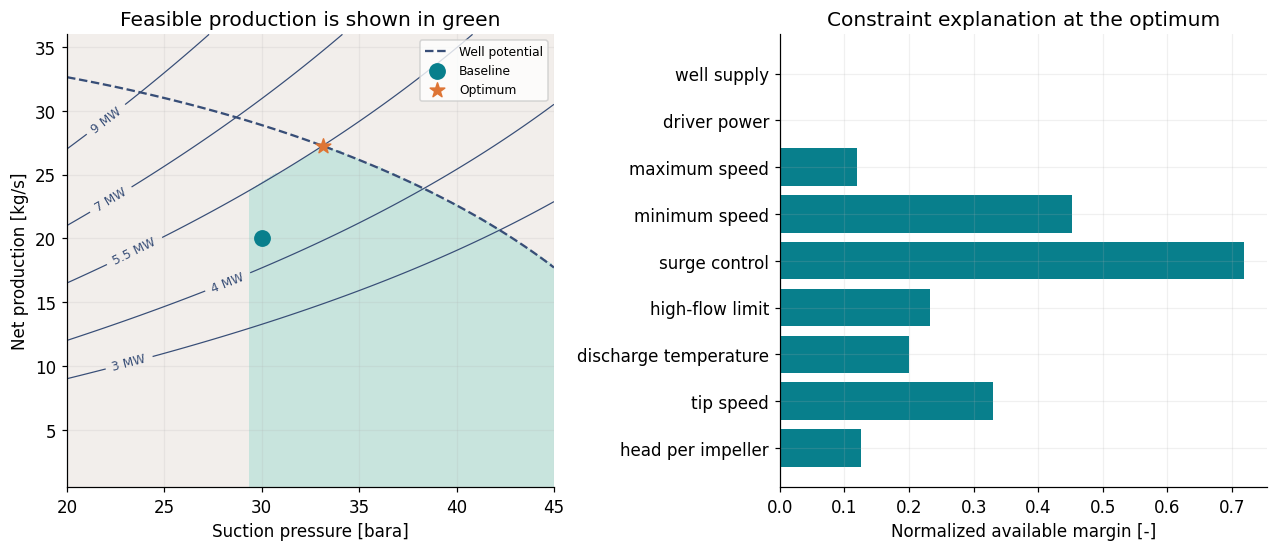

In [17]:
pressure_scan = np.linspace(20.0, 45.0, 101)
flow_scan = np.linspace(0.5, 36.0, 143)
feasibility = np.zeros((len(flow_scan), len(pressure_scan)), dtype=bool)
power_surface = np.empty_like(feasibility, dtype=float)
for column, pressure in enumerate(pressure_scan):
    for row, flow in enumerate(flow_scan):
        point = operating_point(pressure, flow)
        feasibility[row, column] = point["Feasible"]
        power_surface[row, column] = point["Power [kW]"] / 1000.0
feasible_rates = np.broadcast_to(flow_scan[:, None], feasibility.shape)[feasibility]
assert feasible_rates.size > 0
grid_best_flow = float(feasible_rates.max())
assert optimum["Net flow [kg/s]"] >= grid_best_flow - 1e-6
assert optimum["Net flow [kg/s]"] - grid_best_flow < 0.5

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.9), layout="constrained")
axes[0].contourf(
    pressure_scan,
    flow_scan,
    feasibility.astype(int),
    levels=[-0.5, 0.5, 1.5],
    colors=["#f2eeeb", "#c8e4dd"],
)
contours = axes[0].contour(
    pressure_scan,
    flow_scan,
    power_surface,
    levels=[3.0, 4.0, 5.5, 7.0, 9.0],
    colors="#384e77",
    linewidths=0.8,
)
axes[0].clabel(contours, fmt="%g MW", fontsize=8)
axes[0].plot(
    pressure_scan,
    0.68 * np.sqrt(52.0**2 - pressure_scan**2),
    "--",
    label="Well potential",
    color="#384e77",
)
for point, label, marker in [(baseline, "Baseline", "o"), (optimum, "Optimum", "*")]:
    axes[0].scatter(
        point["Suction [bara]"],
        point["Net flow [kg/s]"],
        label=label,
        marker=marker,
        s=100,
        zorder=5,
    )
axes[0].set(
    xlabel="Suction pressure [bara]",
    ylabel="Net production [kg/s]",
    title="Feasible production is shown in green",
)
axes[0].legend(fontsize=8)
margin_names = list(optimum["margins"])
margin_values = np.array(list(optimum["margins"].values()))
axes[1].barh(
    margin_names,
    margin_values,
    color=["#de7535" if abs(value) < 1e-5 else "#087f8c" for value in margin_values],
)
axes[1].axvline(0, color="#333333", lw=1)
axes[1].set(
    xlabel="Normalized available margin [-]", title="Constraint explanation at the optimum"
)
axes[1].invert_yaxis()
plt.show()
print(f"Independent 101 × 143 grid best: {grid_best_flow:.3f} kg/s")
print(
    "Continuous optimum exceeds the grid best by "
    f"{optimum['Net flow [kg/s]'] - grid_best_flow:.3f} kg/s"
)

## 14. Is a larger driver enough?

A larger driver helps only until another constraint becomes active. The same installed geometry,
synthetic map, speed limits and temperatures are used for every case below. Changing driver
capacity does not authorize a speed increase or change the impeller dimensions.

Reservoir pressure is stepped through 52, 45 and 38 bara. These are independent steady states,
not a material-balance reservoir depletion forecast. Their purpose is to expose changes in the
limiting constraint over field life.

,Reservoir [bara],Driver [MW],Net production [kg/s],Suction [bara],Power [MW],Speed [rpm],Discharge [°C],Limiting constraints
0,52.0,4.5,25.19168,36.49042,4.50000,16201.76907,122.02906,"well supply, driver power"
1,52.0,5.5,27.26073,33.11869,5.50000,17430.16047,131.97928,"well supply, driver power"
2,52.0,6.5,28.84165,30.08383,6.50000,18636.16218,141.92842,"well supply, driver power"
3,52.0,8.0,29.14681,29.44092,6.72619,18906.63224,144.17597,"well supply, head per impeller"
4,45.0,4.5,21.46834,32.06660,4.50000,17388.52871,135.31186,"well supply, driver power"
5,45.0,5.5,23.14231,29.44092,5.34053,18440.51264,144.17597,"well supply, head per impeller"
6,45.0,6.5,23.14231,29.44092,5.34053,18440.51264,144.17597,"well supply, head per impeller"
7,45.0,8.0,23.14231,29.44092,5.34053,18440.51264,144.17597,"well supply, head per impeller"
8,38.0,4.5,16.33745,29.44092,3.77018,17924.84858,144.17597,"well supply, head per impeller"
9,38.0,5.5,16.33745,29.44092,3.77018,17924.84858,144.17597,"well supply, head per impeller"


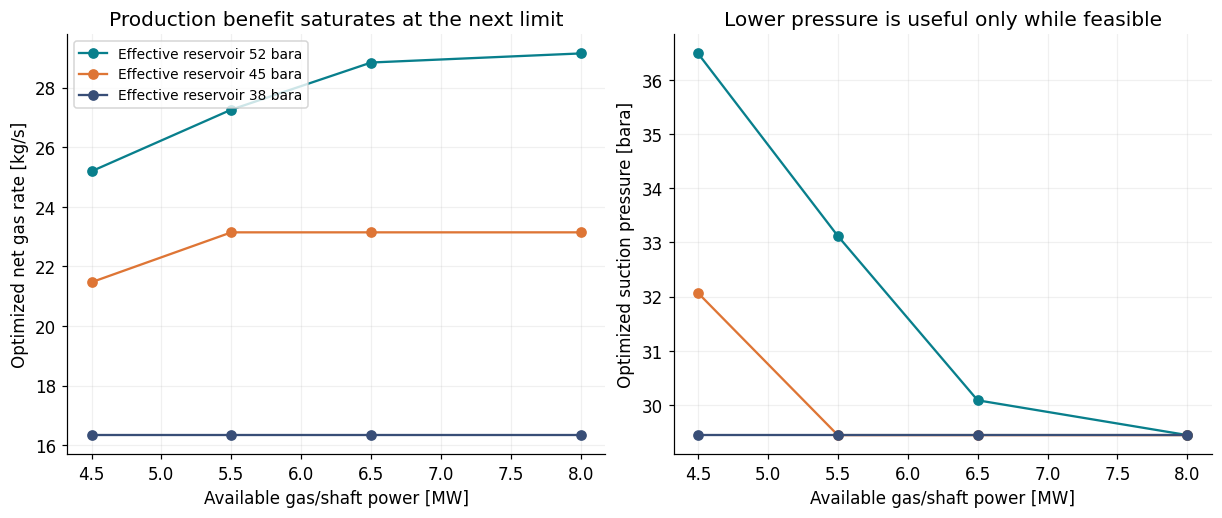

In [18]:
scenario_records = []
for reservoir_pressure in [52.0, 45.0, 38.0]:
    for driver_capacity in [4500.0, 5500.0, 6500.0, 8000.0]:
        point, attempts = optimize_production(reservoir_pressure, driver_capacity)
        active = [key for key, value in point["margins"].items() if abs(value) < 1e-5]
        scenario_records.append(
            {
                "Reservoir [bara]": reservoir_pressure,
                "Driver [MW]": driver_capacity / 1000.0,
                "Net production [kg/s]": point["Net flow [kg/s]"],
                "Suction [bara]": point["Suction [bara]"],
                "Power [MW]": point["Power [kW]"] / 1000.0,
                "Speed [rpm]": point["Speed [rpm]"],
                "Discharge [°C]": point["Discharge [°C]"],
                "Limiting constraints": ", ".join(active),
            }
        )
scenario_table = pd.DataFrame(scenario_records)
display(scenario_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), layout="constrained")
for reservoir_pressure, group in scenario_table.groupby("Reservoir [bara]", sort=False):
    label = f"Effective reservoir {reservoir_pressure:.0f} bara"
    axes[0].plot(group["Driver [MW]"], group["Net production [kg/s]"], "o-", label=label)
    axes[1].plot(group["Driver [MW]"], group["Suction [bara]"], "o-", label=label)
axes[0].set(
    xlabel="Available gas/shaft power [MW]",
    ylabel="Optimized net gas rate [kg/s]",
    title="Production benefit saturates at the next limit",
)
axes[1].set(
    xlabel="Available gas/shaft power [MW]",
    ylabel="Optimized suction pressure [bara]",
    title="Lower pressure is useful only while feasible",
)
axes[0].legend(fontsize=9)
plt.show()

The active-constraint column shows when the per-impeller head limit replaces the power limit.
Different map shapes or speed ranges could make speed or high-flow limits active instead. A flat production response to additional
driver power is therefore meaningful: a larger motor alone does not remove the head-per-impeller, aerodynamic or
speed restriction. Restaging, a new rotor/casing, parallel compression or a lower export-pressure
requirement are different projects requiring new calculations.

## 15. Anti-surge recycle: internal throughput is not production

For the teaching control model, the minimum stable compressor flow is calculated at the control
flow coefficient, and internal recycle makes up any shortfall:

$$\dot m_c=\max(\dot m_{\mathrm{net}},\dot m_{\mathrm{control}}),\qquad
\dot m_{\mathrm{recycle}}=\dot m_c-\dot m_{\mathrm{net}}$$

Only the net flow is exported. Gas power uses **compressor** throughput, so recycle consumes
energy without increasing sales. This steady control calculation does not simulate surge
oscillations, anti-surge valve dynamics or a controller tuning study.

We assume the recycle returns to exactly the suction temperature, pressure and composition after
an isenthalpic pressure reduction and thermal conditioning. This makes the mixing balance
algebraically closed. The required conditioning duty is included below; a real loop needs a
valve, cooler/heater capacity, piping pressure losses and a dynamic study.

,Suction [bara],Net flow [kg/s],Power [kW],Speed [rpm],Discharge [°C],Specific energy [kWh/t net],Compressor flow [kg/s],Recycle [kg/s]
0,30.0,3.0,2391.72764,17312.49489,142.21851,221.45626,10.57986,7.57986


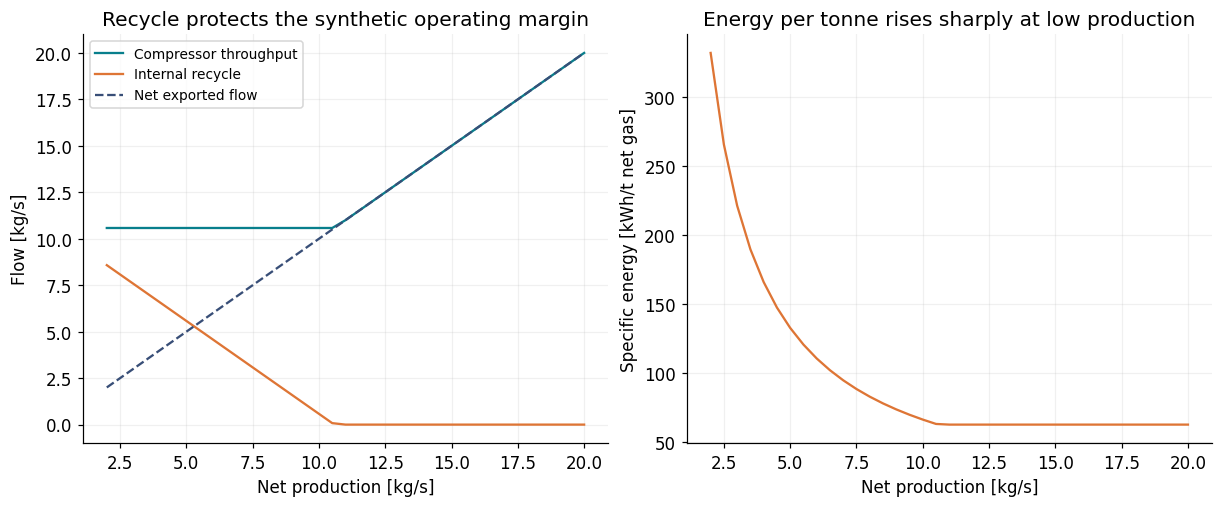

In [19]:
recycle_rows = []
for net_rate in np.linspace(2.0, 20.0, 37):
    point = operating_point(P_DESIGN, net_rate)
    recycle_rows.append({key: value for key, value in point.items() if key != "margins"})
recycle_table = pd.DataFrame(recycle_rows)
low_rate = operating_point(P_DESIGN, 3.0)
display(
    pd.DataFrame([low_rate])[list(summary_columns) + ["Compressor flow [kg/s]", "Recycle [kg/s]"]]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
axes[0].plot(
    recycle_table["Net flow [kg/s]"],
    recycle_table["Compressor flow [kg/s]"],
    label="Compressor throughput",
)
axes[0].plot(
    recycle_table["Net flow [kg/s]"], recycle_table["Recycle [kg/s]"], label="Internal recycle"
)
axes[0].plot(
    recycle_table["Net flow [kg/s]"],
    recycle_table["Net flow [kg/s]"],
    "--",
    label="Net exported flow",
)
axes[0].set(
    xlabel="Net production [kg/s]",
    ylabel="Flow [kg/s]",
    title="Recycle protects the synthetic operating margin",
)
axes[0].legend(fontsize=9)
axes[1].plot(
    recycle_table["Net flow [kg/s]"], recycle_table["Specific energy [kWh/t net]"], color="#de7535"
)
axes[1].set(
    xlabel="Net production [kg/s]",
    ylabel="Specific energy [kWh/t net gas]",
    title="Energy per tonne rises sharply at low production",
)
plt.show()

In [20]:
recycle_process = run_case(P_DESIGN, low_rate["Compressor flow [kg/s]"])
recycle_inlet_h = recycle_process["inlet"].getFluid().getEnthalpy("J/kg") / 1000.0
cooled_export_h = recycle_process["export"].getFluid().getEnthalpy("J/kg") / 1000.0
compressor_work = recycle_process["power_kw"]
main_cooler_duty = recycle_process["aftercooler"].getDuty() / 1000.0
conditioning_duty = low_rate["Recycle [kg/s]"] * (recycle_inlet_h - cooled_export_h)
external_enthalpy_rise = low_rate["Net flow [kg/s]"] * (cooled_export_h - recycle_inlet_h)
loop_energy_residual = (
    compressor_work + main_cooler_duty + conditioning_duty - external_enthalpy_rise
)
loop_mass_residual = (
    low_rate["Compressor flow [kg/s]"] - low_rate["Recycle [kg/s]"] - low_rate["Net flow [kg/s]"]
)
display(
    pd.DataFrame(
        [
            ["Work into gas", compressor_work],
            ["Main aftercooler heat into gas", main_cooler_duty],
            ["Recycle conditioning heat into gas", conditioning_duty],
            ["Net exported enthalpy minus fresh-feed enthalpy", external_enthalpy_rise],
            ["External energy residual", loop_energy_residual],
        ],
        columns=["Energy term", "kW"],
    )
)
print(f"Algebraic recycle mass residual: {loop_mass_residual:.3e} kg/s")
print("Positive heat is into the gas; a negative duty is heat removal.")

Algebraic recycle mass residual: 0.000e+00 kg/s
Positive heat is into the gas; a negative duty is heat removal.


,Energy term,kW
0,Work into gas,2.39173e+03
1,Main aftercooler heat into gas,-3.04871e+03
2,Recycle conditioning heat into gas,4.70688e+02
3,Net exported enthalpy minus fresh-feed enthalpy,-1.86291e+02
4,External energy residual,2.27374e-13


## 16. Sensitivity to well deliverability and compressor efficiency

Nine deterministic scenarios vary the well productivity parameter and assumed constant
polytropic efficiency. The installed rotor stays fixed. The resulting range is a sensitivity
range, **not a probability interval**. Efficiency uncertainty affects power, required polytropic
head and discharge temperature through a fresh NeqSim calculation.

The preliminary work coefficient, synthetic map shape and stability boundaries are larger
unqualified assumptions than the numerical solver tolerances. Replace them with supplier data
before assigning engineering confidence to the production numbers.

,Productivity [kg/(s bar)],Polytropic efficiency [-],Net flow [kg/s],Suction [bara],Power [kW],Speed [rpm],Minimum margin [-]
0,0.58,0.74,24.05132,31.37551,5500.00000,17883.77882,8.78349e-13
1,0.58,0.78,24.53862,30.23303,5500.00000,18254.65740,6.44936e-13
2,0.58,0.82,24.95543,29.20122,5478.02158,18596.85181,1.95260e-11
3,0.68,0.74,26.64789,34.18033,5500.00000,17097.33293,3.89614e-14
4,0.68,0.78,27.26073,33.11869,5500.00000,17430.16047,8.97652e-14
5,0.68,0.82,27.82729,32.08348,5500.00000,17765.01382,1.38201e-13
6,0.78,0.74,28.93154,36.44454,5500.00000,16504.56137,-1.01027e-11
7,0.78,0.78,29.66686,35.45958,5500.00000,16808.62634,-1.00706e-13
8,0.78,0.82,30.35087,34.49500,5500.00000,17114.59885,1.63899e-13


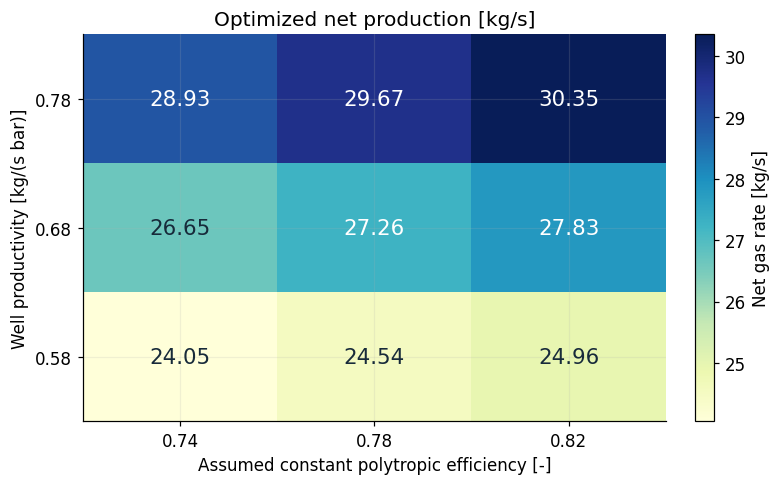

In [21]:
sensitivity_records = []
for productivity in [0.58, 0.68, 0.78]:
    for efficiency in [0.74, 0.78, 0.82]:
        point, attempts = optimize_production(productivity=productivity, efficiency=efficiency)
        sensitivity_records.append(
            {
                "Productivity [kg/(s bar)]": productivity,
                "Polytropic efficiency [-]": efficiency,
                "Net flow [kg/s]": point["Net flow [kg/s]"],
                "Suction [bara]": point["Suction [bara]"],
                "Power [kW]": point["Power [kW]"],
                "Speed [rpm]": point["Speed [rpm]"],
                "Minimum margin [-]": min(point["margins"].values()),
            }
        )
sensitivity_table = pd.DataFrame(sensitivity_records)
display(sensitivity_table)
pivot = sensitivity_table.pivot(
    index="Productivity [kg/(s bar)]",
    columns="Polytropic efficiency [-]",
    values="Net flow [kg/s]",
)
fig, ax = plt.subplots(figsize=(7, 4.3), layout="constrained")
mesh = ax.imshow(pivot.to_numpy(), cmap="YlGnBu", aspect="auto", origin="lower")
ax.set_xticks(np.arange(3), [f"{value:.2f}" for value in pivot.columns])
ax.set_yticks(np.arange(3), [f"{value:.2f}" for value in pivot.index])
for row in range(3):
    for column in range(3):
        value = pivot.iloc[row, column]
        color = "white" if value > np.mean(pivot.to_numpy()) else "#172a3a"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=color, fontsize=14)
ax.set(
    xlabel="Assumed constant polytropic efficiency [-]",
    ylabel="Well productivity [kg/(s bar)]",
    title="Optimized net production [kg/s]",
)
fig.colorbar(mesh, ax=ax, label="Net gas rate [kg/s]")
plt.show()

## 17. What the calculations establish—and what a vendor must supply

| Layer | Demonstrated here | Additional engineering inputs |
|---|---|---|
| Thermodynamics | SRK head, work, phase checks, full-flow replay | Fluid/PVT validation, contaminants and all design cases |
| Preliminary impeller sizing | Coupled diameter, speed, equal-head count and inlet coefficient | Blade angles/widths, slip, diffuser, return channels, stage matching |
| Operating envelope | Transparent fixed-geometry synthetic map | Measured/corrected vendor maps, Reynolds/Mach effects and surge/choke evidence |
| Production | Constrained optimum, active limits, sensitivity | Calibrated reservoir, wellbore and gathering network models |
| Recycle | Net versus internal flow, steady energy balance | Valve capacity, cooler limits, piping and controller dynamics |
| Mechanical design | Unit-labelled concept design export | Materials, stress, fatigue, rotor dynamics, bearings, seals and applicable code review |

The screening flag is deliberately narrower than complete compressor acceptance. The final
optimized point is validated against the frozen synthetic operating map; the design flag is not
recomputed to bless a redesigned machine. Geometry and operating qualification remain distinct.

The corrected sizing behavior is tracked by [NeqSim #3676](https://github.com/equinor/neqsim/issues/3676)
and [PR #3695](https://github.com/equinor/neqsim/pull/3695). No new library defect was identified by
this notebook's executed checks. The synthetic map and well relation are disclosed notebook
assumptions, rather than claims of missing NeqSim functionality.

## 18. Validation and reusable results

The acceptance checks below test energy and material conservation, coupled geometry identities,
reference behavior, independent candidate selection, unit conversion, stage allocation, frozen
geometry, map closure, constrained optimization, grid comparison, full-flow replay and recycle
closure. They do not claim experimental validation of the synthetic map.

A separate rendered review covers every Markdown cell, equation, result table and static figure.
The repository maintenance record stores that inspection evidence and the exact runtime identity.
The JSON and CSV files written here retain the design basis, scenario results and numerical checks.
Their main contents remain visible in this notebook.

In [22]:
identity_errors = []
for speed, (compressor, sizing) in reference_designs.items():
    diameter = sizing.getImpellerDiameter() / 1000.0
    tip = sizing.getTipSpeed()
    identity_errors.append(abs(tip - math.pi * diameter * speed / 60.0))
    identity_errors.append(
        abs(
            compressor.getPolytropicFluidHead()
            - sizing.getNumberOfStages() * 0.50 * tip**2 / 1000.0
        )
    )
    identity_errors.append(
        abs(
            sizing.getFlowCoefficient()
            - compressor.getInletStream().getFlowRate("m3/sec") / (diameter**2 * tip)
        )
    )

checks = {
    "molar composition sums to one": math.isclose(sum(COMPOSITION.values()), 1.0),
    "total mass conserved": abs(mass_residual) < 1e-9,
    "components conserved": max(component_residuals) < 1e-10,
    "gas power equals enthalpy rise": abs(energy_residual_kw) < 1e-6,
    "head/efficiency equals gas work": abs(
        design_case["head_kj_kg"] / ETA_POLY - design_case["specific_work_kj_kg"]
    )
    < 1e-6,
    "actual volume flow matches mass/density": math.isclose(
        design_case["actual_m3_s"], M_DESIGN / design_case["density_kg_m3"], rel_tol=1e-9
    ),
    "perfect-gas estimate within broad 25% screening band": abs(ideal_head_difference) < 25.0,
    "reference coupled head/speed/flow identities": max(identity_errors) < 1e-8,
    "6000 rpm reference rejected": not reference_designs[6000.0][1].isImpellerSizingFeasible(),
    "18000 rpm reference accepted": bool(reference_designs[18000.0][1].isImpellerSizingFeasible()),
    "independent candidate matches Java": math.isclose(
        selected_candidate["Diameter [mm]"], design.getImpellerDiameter(), rel_tol=1e-12
    ),
    "equal-head stage allocation": bool(
        np.allclose(stage_audit["Head [kJ/kg]"], head_target_per_stage, atol=1e-7, rtol=0)
    ),
    "stage reconstruction pressure within 0.5%": abs(stage_pressure_difference) < 0.5,
    "export diameter conversion": math.isclose(
        cad_geometry["impellerDiameter"]["value"] * 1000.0,
        legacy_design["impellerDiameter"],
        rel_tol=1e-12,
    ),
    "stale sizing rejected": stale_rejected,
    "invalid input clears exported geometry": invalid_inputs_cleared,
    "installed rotor remained fixed": geometry_identity
    == (installed.diameter_m, installed.impellers),
    "optimum passes every operating constraint": optimum["Feasible"],
    "map head residual closes": abs(optimum["Map residual [kJ/kg]"]) < 1e-8,
    "full-flow replay power closes": abs(replay_power_error) < 1e-5,
    "full-flow replay head closes": abs(replay_head_error) < 1e-7,
    "continuous optimum consistent with independent grid": (
        -1e-6 <= optimum["Net flow [kg/s]"] - grid_best_flow < 0.5
    ),
    "all sensitivity cases feasible": bool(
        (sensitivity_table["Minimum margin [-]"] >= -1e-6).all()
    ),
    "low-rate case requires recycle": low_rate["Recycle [kg/s]"] > 0,
    "recycle external mass balance": abs(loop_mass_residual) < 1e-9,
    "recycle external energy balance": abs(loop_energy_residual) < 1e-6,
}
for reservoir_pressure, group in scenario_table.groupby("Reservoir [bara]"):
    checks[f"more driver power does not lower production at {reservoir_pressure:g} bara"] = bool(
        np.all(np.diff(group["Net production [kg/s]"].to_numpy()) > -1e-5)
    )
check_table = pd.DataFrame({"Engineering check": list(checks), "Passed": list(checks.values())})
display(check_table)
assert all(checks.values()), [name for name, passed in checks.items() if not passed]
print(f"All {len(checks)} engineering checks passed.")
print(
    "Independent equation and conservation evidence; synthetic-map predictions remain uncalibrated."
)

All 29 engineering checks passed.
Independent equation and conservation evidence; synthetic-map predictions remain uncalibrated.


,Engineering check,Passed
0,molar composition sums to one,True
1,total mass conserved,True
2,components conserved,True
3,gas power equals enthalpy rise,True
4,head/efficiency equals gas work,True
5,actual volume flow matches mass/density,True
6,perfect-gas estimate within broad 25% screening band,True
7,reference coupled head/speed/flow identities,True
8,6000 rpm reference rejected,True
9,18000 rpm reference accepted,True


In [23]:
provenance = {
    "source_repository": "equinor/neqsim",
    "source_commit": NEQSIM_SOURCE_REF,
    "source_pr": 3695,
    "source_jar_sha256": actual_hash,
    "build_method": build_method,
    "python": platform.python_version(),
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "packages": {package: version(package) for package in required_packages},
    "composition_mole_fraction": COMPOSITION,
    "installed_diameter_m": installed.diameter_m,
    "installed_impellers": installed.impellers,
    "map_provenance": "Synthetic head coefficient curve; constant efficiency; not vendor data",
    "well_provenance": "Synthetic pressure-squared aggregate deliverability",
    "checks_passed": len(checks),
}
for name, table in {
    "design_thermodynamics": thermo_table,
    "reference_sizing": reference_table,
    "stage_audit": stage_audit,
    "synthetic_map": map_table,
    "production_scenarios": scenario_table,
    "sensitivity": sensitivity_table,
    "anti_surge_recycle": recycle_table,
    "engineering_checks": check_table,
}.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
(OUTPUT_DIR / "runtime_and_model_provenance.json").write_text(
    json.dumps(provenance, indent=2, allow_nan=False)
)
(OUTPUT_DIR / "optimized_operating_point.json").write_text(
    json.dumps(optimum, indent=2, allow_nan=False)
)
archive_path = shutil.make_archive("compressor_study_outputs", "zip", OUTPUT_DIR)
print("Reusable output files:")
for output_file in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {output_file.name}: {output_file.stat().st_size:,} bytes")
print("ZIP:", archive_path)
display(
    Markdown(
        f"**Calculated outcome:** {installed.impellers} impellers of "
        f"{installed.diameter_m * 1000:.1f} mm at the design point. The fixed-machine "
        f"production example increases net rate from {baseline['Net flow [kg/s]']:.1f} "
        f"to {optimum['Net flow [kg/s]']:.2f} kg/s at {optimum['Suction [bara]']:.2f} bara "
        f"suction and {optimum['Power [kW]'] / 1000:.2f} MW. "
        f"The active limits are **{', '.join(active_constraints)}**."
    )
)

Reusable output files:
  anti_surge_recycle.csv: 8,773 bytes
  design_thermodynamics.csv: 445 bytes
  engineering_checks.csv: 1,191 bytes
  optimized_operating_point.json: 986 bytes
  preliminary_compressor_design.json: 5,737 bytes
  production_scenarios.csv: 1,717 bytes
  reference_sizing.csv: 276 bytes
  runtime_and_model_provenance.json: 1,055 bytes
  sensitivity.csv: 1,080 bytes
  stage_audit.csv: 743 bytes
  synthetic_map.csv: 22,272 bytes
ZIP: /workspace/scratch/7242e1797717/compressor_study_outputs.zip


**Calculated outcome:** 6 impellers of 257.2 mm at the design point. The fixed-machine production example increases net rate from 20.0 to 27.26 kg/s at 33.12 bara suction and 5.50 MW. The active limits are **well supply, driver power**.

## 19. Exercises and extensions

1. Change the design pressure ratio and mass flow. Explain which preliminary sizing limit changes
   first; retain every failed candidate and its diagnostic.
2. Add an intercooled second casing. Compare total work, discharge temperature, impeller counts
   and stage-inlet flow coefficients, distinguishing wheels from cooled compression sections.
3. Replace the synthetic map with supplier data using the NeqSim compressor chart API. Preserve
   map units, reference gas, correction basis and surge-control-margin definition.
4. Replace the toy well relation with a calibrated well/gathering model. Compare the optimum and
   its bottlenecks across reservoir realizations.
5. Add motor/gearbox losses, cooling capacity, a recycle valve and controller dynamics; examine
   how the feasible operating envelope changes.
6. Use the unit-labelled design export for a concept CAD envelope via the companion 3D notebook.
   Keep impeller feasibility diagnostics with the model; do not infer blade profiles from diameter.

## 20. Sources and model provenance

- [PR #3695](https://github.com/equinor/neqsim/pull/3695) and
  [issue #3676](https://github.com/equinor/neqsim/issues/3676): head–speed–diameter consistency,
  preliminary limits and regression case. All sizing implementation claims refer to the pinned
  commit, rather than a later moving branch.
- [Pinned CompressorMechanicalDesign source](https://github.com/equinor/neqsim/blob/ef8093d6a41c2ae25fae2cbf300275bfd6446102/src/main/java/neqsim/process/mechanicaldesign/compressor/CompressorMechanicalDesign.java)
  and [pinned sizing guide](https://github.com/equinor/neqsim/blob/ef8093d6a41c2ae25fae2cbf300275bfd6446102/docs/process/CompressorMechanicalDesign.md).
- [NeqSim compressor maps documentation](https://equinor.github.io/neqsim/process/equipment/compressor_curves):
  existing chart APIs for replacing the explicitly synthetic map in this notebook.
- [NASA Glenn: centrifugal compressors](https://www.grc.nasa.gov/www/k-12/airplane/centrf.html):
  physical operating principle and the role of speed, pressure ratio and efficiency.
- [NASA Glenn: compressor thermodynamics](https://www.grc.nasa.gov/WWW/K-12/BGP/compth.html):
  ideal-gas work and temperature relations used for the independent equation check.
- [NASA HECC data archive guide](https://ntrs.nasa.gov/citations/20250000831):
  an example of research-quality compressor data and provenance. No HECC measurements are used
  or claimed as validation of the synthetic natural-gas map here.

All gas compositions, well/driver scenarios and synthetic operating-map coefficients were created
for this notebook. No proprietary data or measured production uplift is represented.